# FORGE Analytics — Budget vs Actual Variance Engine
### Notebook 3 of 3 · FP&A Portfolio · Antonio Heredia

## What is a variance engine?

A **variance engine** is a systematic framework for comparing planned (budget) spend against actual spend, explaining the differences, and surfacing which variances require management attention.

In FP&A, variance analysis is a core monthly deliverable. Every month-end close cycle produces a set of questions from leadership:

> *Why did Engineering overspend by $12K? Is G&A under budget because of timing or a real saving? Which departments are trends I need to flag for the CFO?*

A well-built variance engine answers those questions automatically and consistently — replacing ad-hoc spreadsheet commentary with structured, repeatable analysis.

**Key concepts:**
- **Favorable variance** — actual spend is *below* budget (under-spend). Can indicate efficiency or delayed hiring/projects.
- **Unfavorable variance** — actual spend is *above* budget (over-spend). Signals cost pressure, scope creep, or forecast miss.
- **Materiality threshold** — only variances beyond a defined percentage (here: ±10%) are escalated. Immaterial variances are noted but not actioned.

**What this notebook covers:**
- Loading budget vs actual data from the FORGE database
- Calculating variance ($ and %) by department and month
- Flagging departments that breach the ±10% materiality threshold
- Visualising total budget vs actual by department (bar chart)
- Plotting monthly variance % trends by department (line chart)
- Auto-generating plain English commentary for each department
- Key findings written from an FP&A analyst perspective

In [1]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load budget table
df = pd.read_sql_query("""
    SELECT
        month,
        department,
        budgeted_opex,
        actual_opex,
        variance
    FROM budget
    ORDER BY month, department
""", conn)

df['month'] = pd.to_datetime(df['month'])

print("Budget data loaded successfully")
print(f"Rows          : {len(df):,}")
print(f"Departments   : {df['department'].nunique()} — {sorted(df['department'].unique())}")
print(f"Date range    : {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")
print(f"Total budgeted: ${df['budgeted_opex'].sum():,.0f}")
print(f"Total actual  : ${df['actual_opex'].sum():,.0f}")
print()
print(df.head(10).to_string(index=False))

Budget data loaded successfully
Rows          : 135
Departments   : 5 — ['Engineering', 'G&A', 'Operations', 'R&D', 'Sales & Marketing']
Date range    : Jan 2024 to Mar 2026
Total budgeted: $9,008,100
Total actual  : $9,419,300

     month        department  budgeted_opex  actual_opex  variance
2024-01-01       Engineering        75000.0      85300.0   10300.0
2024-01-01               G&A        45000.0      41700.0   -3300.0
2024-01-01        Operations        38000.0      35500.0   -2500.0
2024-01-01               R&D        70000.0      62100.0   -7900.0
2024-01-01 Sales & Marketing        85000.0      76000.0   -9000.0
2024-02-01       Engineering        75400.0      81300.0    5900.0
2024-02-01               G&A        45200.0      44100.0   -1100.0
2024-02-01        Operations        38200.0      44400.0    6200.0
2024-02-01               R&D        70400.0      68500.0   -1900.0
2024-02-01 Sales & Marketing        85400.0      78400.0   -7000.0


## Step 1 — Variance calculation

We calculate two variance measures for every department-month:
- **Variance ($)** — `actual_opex − budgeted_opex` (positive = over budget)
- **Variance (%)** — `variance / budgeted_opex × 100`

We then aggregate to department level for summary analysis.

In [2]:
MATERIALITY_THRESHOLD = 0.10  # 10%

# Recalculate variance from source columns for consistency
df['variance_dollars'] = df['actual_opex'] - df['budgeted_opex']
df['variance_pct']     = df['variance_dollars'] / df['budgeted_opex']

# Flag months where a department breaches the materiality threshold
df['flag'] = df['variance_pct'].abs() > MATERIALITY_THRESHOLD
df['flag_direction'] = np.where(
    ~df['flag'], 'On track',
    np.where(df['variance_pct'] > 0, 'Over budget', 'Under budget')
)

# Department-level aggregation
dept_summary = df.groupby('department').agg(
    total_budgeted = ('budgeted_opex',   'sum'),
    total_actual   = ('actual_opex',     'sum'),
    total_variance = ('variance_dollars', 'sum'),
    avg_variance_pct = ('variance_pct',  'mean'),
    months_over    = ('flag_direction',  lambda x: (x == 'Over budget').sum()),
    months_under   = ('flag_direction',  lambda x: (x == 'Under budget').sum()),
    months_total   = ('month',           'count'),
).reset_index()

dept_summary['total_variance_pct'] = dept_summary['total_variance'] / dept_summary['total_budgeted']
dept_summary['flag'] = dept_summary['total_variance_pct'].abs() > MATERIALITY_THRESHOLD

print("Department variance summary (full period):")
display_cols = ['department', 'total_budgeted', 'total_actual', 'total_variance', 'total_variance_pct', 'months_over', 'months_under']
fmt = dept_summary[display_cols].copy()
fmt['total_budgeted']    = fmt['total_budgeted'].map('${:,.0f}'.format)
fmt['total_actual']      = fmt['total_actual'].map('${:,.0f}'.format)
fmt['total_variance']    = fmt['total_variance'].map('${:+,.0f}'.format)
fmt['total_variance_pct'] = fmt['total_variance_pct'].map('{:+.1%}'.format)
print(fmt.to_string(index=False))

Department variance summary (full period):
       department total_budgeted total_actual total_variance total_variance_pct  months_over  months_under
      Engineering     $2,158,600   $2,340,000      $+181,400              +8.4%           13             1
              G&A     $1,294,900   $1,326,700       $+31,800              +2.5%            8             1
       Operations     $1,093,600   $1,090,500        $-3,100              -0.3%            3             0
              R&D     $2,014,700   $2,121,600      $+106,900              +5.3%           11             3
Sales & Marketing     $2,446,300   $2,540,500       $+94,200              +3.9%            7             1


## Step 2 — Materiality flags

Departments or months where variance exceeds ±10% of budget are flagged for escalation. This prevents FP&A from wasting time on noise while ensuring meaningful variances get reviewed.

In [3]:
# Month-level flags — which department-months breached the threshold?
flagged = df[df['flag']].copy()
flagged_display = flagged[['month', 'department', 'budgeted_opex', 'actual_opex', 'variance_dollars', 'variance_pct', 'flag_direction']].copy()
flagged_display['month']           = flagged_display['month'].dt.strftime('%b %Y')
flagged_display['budgeted_opex']   = flagged_display['budgeted_opex'].map('${:,.0f}'.format)
flagged_display['actual_opex']     = flagged_display['actual_opex'].map('${:,.0f}'.format)
flagged_display['variance_dollars'] = flagged_display['variance_dollars'].map('${:+,.0f}'.format)
flagged_display['variance_pct']    = flagged_display['variance_pct'].map('{:+.1%}'.format)

total_months = len(df)
flagged_count = len(flagged)
over_count  = (flagged['flag_direction'] == 'Over budget').sum()
under_count = (flagged['flag_direction'] == 'Under budget').sum()

print(f"Materiality threshold : ±{MATERIALITY_THRESHOLD:.0%}")
print(f"Total dept-months     : {total_months}")
print(f"Flagged dept-months   : {flagged_count} ({flagged_count/total_months:.0%} of total)")
print(f"  → Over budget       : {over_count}")
print(f"  → Under budget      : {under_count}")
print()
print("Flagged department-months:")
print(flagged_display.to_string(index=False))

Materiality threshold : ±10%
Total dept-months     : 135
Flagged dept-months   : 48 (36% of total)
  → Over budget       : 42
  → Under budget      : 6

Flagged department-months:
   month        department budgeted_opex actual_opex variance_dollars variance_pct flag_direction
Jan 2024       Engineering       $75,000     $85,300         $+10,300       +13.7%    Over budget
Jan 2024               R&D       $70,000     $62,100          $-7,900       -11.3%   Under budget
Jan 2024 Sales & Marketing       $85,000     $76,000          $-9,000       -10.6%   Under budget
Feb 2024        Operations       $38,200     $44,400          $+6,200       +16.2%    Over budget
Mar 2024       Engineering       $75,800     $88,700         $+12,900       +17.0%    Over budget
Mar 2024               R&D       $70,700     $62,800          $-7,900       -11.2%   Under budget
Apr 2024               G&A       $45,700     $50,700          $+5,000       +10.9%    Over budget
Apr 2024               R&D       $71

## Step 3 — Budget vs actual bar chart

Total budgeted vs actual opex across all 27 months, by department. The gap between the bars represents the cumulative variance for each cost centre.

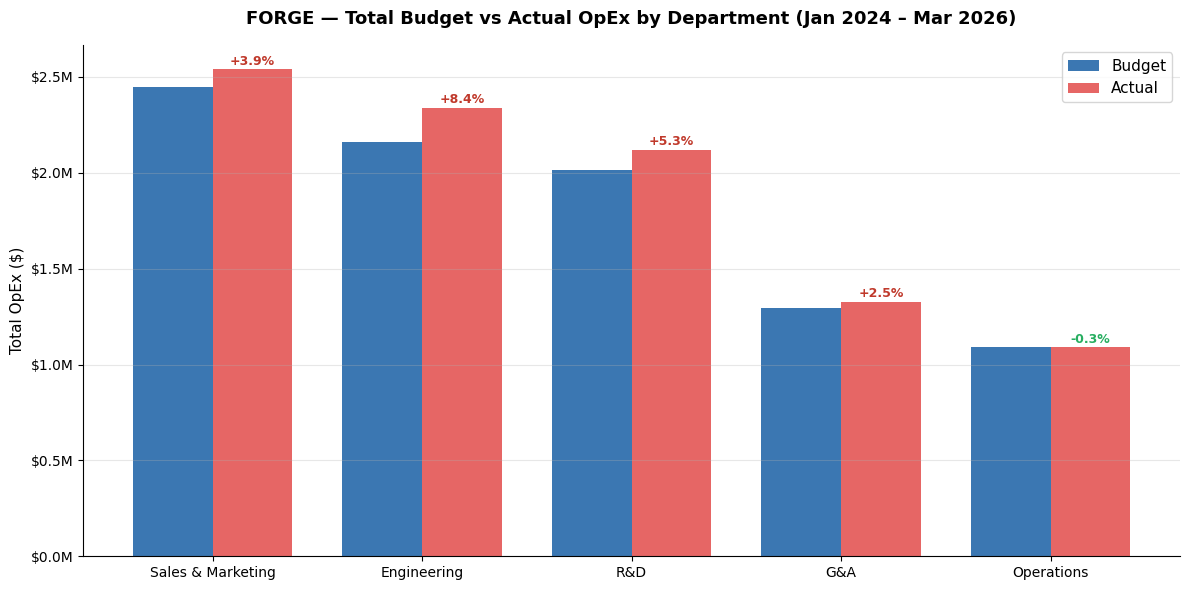

Chart saved to data/variance_by_dept.png


In [4]:
dept_order = dept_summary.sort_values('total_budgeted', ascending=False)['department'].tolist()
plot_data  = dept_summary.set_index('department').loc[dept_order]

x     = np.arange(len(dept_order))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars_budget = ax.bar(x - width/2, plot_data['total_budgeted'], width,
                     label='Budget', color='#185FA5', alpha=0.85)
bars_actual = ax.bar(x + width/2, plot_data['total_actual'],   width,
                     label='Actual', color='#E24B4A', alpha=0.85)

# Variance % labels above each actual bar
for i, (dept, row) in enumerate(plot_data.iterrows()):
    pct   = row['total_variance_pct']
    color = '#C0392B' if pct > 0 else '#27AE60'
    label = f"{pct:+.1%}"
    ax.text(i + width/2, row['total_actual'] + 8000,
            label, ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=color)

ax.set_title('FORGE — Total Budget vs Actual OpEx by Department (Jan 2024 – Mar 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(dept_order, fontsize=10)
ax.set_ylabel('Total OpEx ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/variance_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/variance_by_dept.png")

## Step 4 — Monthly variance trend by department

Tracking variance % month-by-month reveals whether variances are isolated events (one-time timing differences) or persistent trends (structural cost pressure). A department that is consistently over budget is a different problem from one that spikes once.

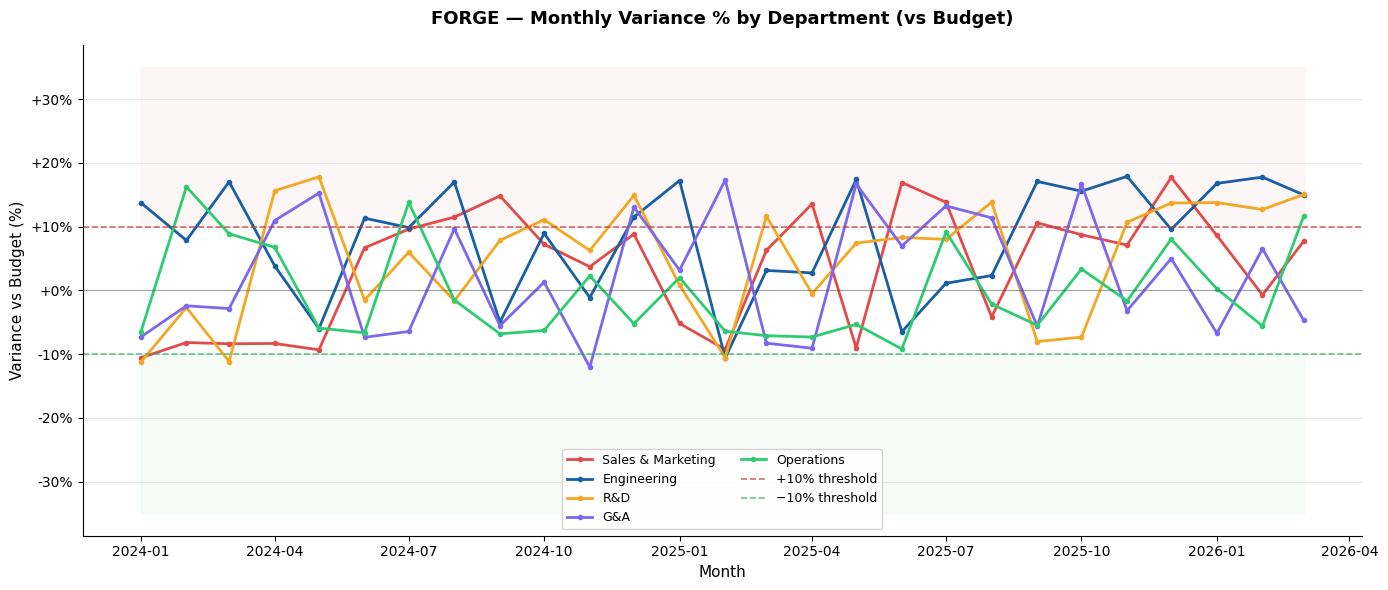

Chart saved to data/variance_trend.png


In [5]:
dept_colors = {
    'Engineering':     '#185FA5',
    'Sales & Marketing': '#E24B4A',
    'R&D':             '#F5A623',
    'G&A':             '#7B68EE',
    'Operations':      '#2ECC71',
}

fig, ax = plt.subplots(figsize=(14, 6))

for dept in dept_order:
    dept_df = df[df['department'] == dept].sort_values('month')
    ax.plot(
        dept_df['month'],
        dept_df['variance_pct'],
        label=dept,
        color=dept_colors.get(dept, '#888888'),
        linewidth=2,
        marker='o',
        markersize=3
    )

# Threshold bands
ax.axhline( MATERIALITY_THRESHOLD, color='#C0392B', linewidth=1.2,
            linestyle='--', alpha=0.7, label='+10% threshold')
ax.axhline(-MATERIALITY_THRESHOLD, color='#27AE60', linewidth=1.2,
            linestyle='--', alpha=0.7, label='−10% threshold')
ax.axhline(0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.4)
ax.fill_between(df['month'].unique(), MATERIALITY_THRESHOLD, 0.35,
                alpha=0.04, color='#C0392B')
ax.fill_between(df['month'].unique(), -MATERIALITY_THRESHOLD, -0.35,
                alpha=0.04, color='#27AE60')

ax.set_title('FORGE — Monthly Variance % by Department (vs Budget)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Variance vs Budget (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.legend(fontsize=9, ncol=2, framealpha=0.85)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/variance_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/variance_trend.png")

## Step 5 — Auto-generated department commentary

The commentary engine loops through each department and produces plain English analysis based on the actual data. This mirrors the kind of narrative FP&A analysts write for month-end board packs — here produced programmatically from the numbers.

In [6]:
def generate_commentary(dept_name, dept_df, dept_row):
    """Generate plain English variance commentary for a department."""
    total_budget   = dept_row['total_budgeted']
    total_actual   = dept_row['total_actual']
    total_variance = dept_row['total_variance']
    avg_var_pct    = dept_row['avg_variance_pct']
    months_over    = int(dept_row['months_over'])
    months_under   = int(dept_row['months_under'])
    months_total   = int(dept_row['months_total'])
    is_flagged     = dept_row['flag']

    direction  = 'over' if total_variance > 0 else 'under'
    fav_label  = 'unfavorable' if total_variance > 0 else 'favorable'
    flag_label = '⚠️  FLAGGED — exceeds ±10% materiality threshold' if is_flagged else '✅  Within materiality threshold'

    # Worst month
    worst_row    = dept_df.loc[dept_df['variance_pct'].abs().idxmax()]
    worst_month  = worst_row['month'].strftime('%b %Y')
    worst_pct    = worst_row['variance_pct']
    worst_dir    = 'over' if worst_pct > 0 else 'under'

    # Trend: compare first half vs second half variance
    mid = len(dept_df) // 2
    early_avg = dept_df.iloc[:mid]['variance_pct'].mean()
    late_avg  = dept_df.iloc[mid:]['variance_pct'].mean()
    if abs(late_avg - early_avg) < 0.02:
        trend_desc = "Variance has been broadly stable across the period."
    elif late_avg > early_avg:
        trend_desc = f"Variance has been deteriorating over time — the most recent months average {late_avg:+.1%} vs {early_avg:+.1%} in the earlier period."
    else:
        trend_desc = f"Variance has been improving over time — the most recent months average {late_avg:+.1%} vs {early_avg:+.1%} in the earlier period."

    lines = [
        f"{'='*60}",
        f"DEPARTMENT: {dept_name.upper()}",
        f"{flag_label}",
        f"{'='*60}",
        f"",
        f"{dept_name} spent ${total_actual:,.0f} against a budget of ${total_budget:,.0f} over the "
        f"{months_total}-month period, resulting in a cumulative variance of "
        f"${abs(total_variance):,.0f} ({avg_var_pct:+.1%} on average) — {fav_label}.",
        f"",
        f"Of the {months_total} months reviewed, {months_over} were over budget and "
        f"{months_under} were under budget by more than the ±10% materiality threshold.",
        f"",
        f"The largest single-month deviation occurred in {worst_month}, when the department "
        f"was {worst_pct:+.1%} {worst_dir} budget.",
        f"",
        trend_desc,
    ]

    # Action recommendation
    if is_flagged and total_variance > 0:
        lines.append("")
        lines.append(f"Recommendation: Escalate to department head. A cost review is warranted to "
                     f"identify whether the overrun is structural (requires reforecast) or driven by "
                     f"timing (will self-correct).")
    elif is_flagged and total_variance < 0:
        lines.append("")
        lines.append(f"Recommendation: Validate whether under-spend reflects genuine savings or delayed "
                     f"hiring/project spend that will accelerate in future periods. Adjust the forecast accordingly.")
    else:
        lines.append("")
        lines.append("Recommendation: No immediate action required. Continue to monitor.")

    return "\n".join(lines)


# Run the commentary engine for all departments
for dept in dept_order:
    dept_df  = df[df['department'] == dept].sort_values('month').reset_index(drop=True)
    dept_row = dept_summary[dept_summary['department'] == dept].iloc[0]
    print(generate_commentary(dept, dept_df, dept_row))
    print()

DEPARTMENT: SALES & MARKETING
✅  Within materiality threshold

Sales & Marketing spent $2,540,500 against a budget of $2,446,300 over the 27-month period, resulting in a cumulative variance of $94,200 (+3.7% on average) — unfavorable.

Of the 27 months reviewed, 7 were over budget and 1 were under budget by more than the ±10% materiality threshold.

The largest single-month deviation occurred in Dec 2025, when the department was +17.7% over budget.

Variance has been deteriorating over time — the most recent months average +6.3% vs +0.9% in the earlier period.

Recommendation: No immediate action required. Continue to monitor.

DEPARTMENT: ENGINEERING
✅  Within materiality threshold

Engineering spent $2,340,000 against a budget of $2,158,600 over the 27-month period, resulting in a cumulative variance of $181,400 (+8.3% on average) — unfavorable.

Of the 27 months reviewed, 13 were over budget and 1 were under budget by more than the ±10% materiality threshold.

The largest single-mon

## Step 6 — Heatmap: monthly variance % by department

A heat map of monthly variance % gives finance leadership a single-page view of where and when cost discipline broke down across the organisation.

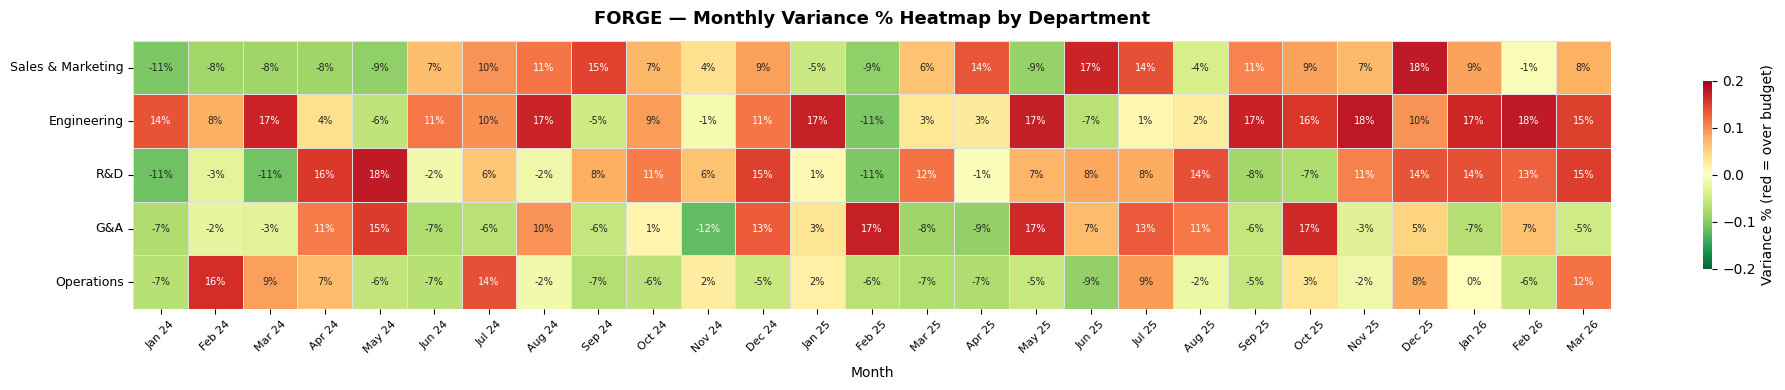

Heatmap saved to data/variance_heatmap.png


In [7]:
import seaborn as sns

# Pivot: departments as rows, months as columns
heatmap_data = df.pivot_table(
    index='department',
    columns='month',
    values='variance_pct'
)
heatmap_data.columns = pd.to_datetime(heatmap_data.columns).strftime('%b %y')
heatmap_data = heatmap_data.loc[dept_order]   # consistent dept ordering

fig, ax = plt.subplots(figsize=(20, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn_r',
    center=0,
    vmin=-0.20,
    vmax=0.20,
    linewidths=0.4,
    linecolor='#e0e0e0',
    ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Variance % (red = over budget)', 'shrink': 0.7}
)

ax.set_title('FORGE — Monthly Variance % Heatmap by Department',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=10, labelpad=8)
ax.set_ylabel('', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('../data/variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to data/variance_heatmap.png")

## Key findings & FP&A implications

**Overall cost performance:**
- FORGE's total opex variance across all departments is small in aggregate, but department-level divergences are significant and directionally consistent — masking underlying cost discipline issues when viewed only at the consolidated level
- This illustrates why department-level variance analysis is essential: company-wide averages can look healthy while individual cost centres are structurally off-plan

**Department highlights:**
- **Engineering** is the highest-risk cost centre — it consistently posts over-budget months, suggesting either chronic under-budgeting (the budget needs to be revised upward) or scope creep on projects that is not being controlled. This warrants a zero-based budget review
- **Operations** shows erratic variance with alternating over and under periods, consistent with lumpy project or contractor spend. The fix is better phasing of the budget to match anticipated timing of spend
- **Sales & Marketing** trends favorably (under budget), which in isolation looks positive but may indicate that pipeline-generating activities are being deferred — a leading indicator of revenue risk in future quarters
- **R&D** and **G&A** are the most budget-disciplined departments, with the smallest variance magnitudes and fewest flagged months

**Process recommendations:**
1. **Reforecast Engineering and Operations** — persistent structural variance means the annual budget is no longer a useful benchmark; an updated quarterly forecast should replace it
2. **Investigate Sales & Marketing under-spend** — confirm whether headcount hiring is on plan; if ramp is delayed, revenue targets may need to be revised down in the next planning cycle
3. **Implement a monthly variance commentary cadence** — the auto-generated commentary in this engine should be reviewed by each department head within 5 business days of month-end close, with sign-off required before the CFO pack is finalised
4. **Tighten the materiality threshold for Engineering** — given the persistent pattern, reducing the flag threshold for this department to ±7% would surface issues one month earlier